## **_Sample Modeling_** (for Reinforcement Learning with LSTM)

* 이 페이지는 "Drying Oven"의 가상 센서 데이터를 이용하여 PPO 모델을 교육하고 예측하는 예제를 구현합니다. 
* 이 페이지에서는 Liear 대신에 LSTM을 이용하도록 변경합니다.

In [5]:
# ----------------------------------------------------
# Global 변수 선언
# ----------------------------------------------------

csv_file_name = "drying_oven_sensor_v3.csv"

#### Step 1 가상 센서 데이터 생성

**시나리오**
* 문 열림이나 외부 간섭으로 인해 내부 온도가 급격히 떨어질 때, 공기의 흐름(풍압)도 함께 불규칙하게 요동치는 상황을 반영했습니다. 보통 문이 열리면 외부 공기 유입으로 인해 압력이 순간적으로 변하고, 시스템은 이를 보정하기 위해 팬 RPM을 급격히 조절하게 됩니다.
* 풍압 요동(Pressure Fluctuation): drop_start 지점에서 풍압이 ±10.0 범위로 크게 튀게 설정했습니다. 이는 실제 환경에서 문이 열릴 때 발생하는 압력 차를 모사한 것입니다.
* 팬 RPM 연동: 풍압이 요동치면 시스템이 이를 보정하려고 하므로, RPM 값도 풍압에 따라 급격히 변화하도록 수식을 연결했습니다.
* 복구 패턴: 온도가 떨어지는 초기에 풍압이 가장 심하게 요동치고, 온도를 다시 올리는 복구 구간에서는 풍압이 서서히 안정화되는 흐름을 가집니다.
* 이 데이터를 사용하여 학습시킬 때, 온도 오차뿐만 아니라 풍압의 급격한 변화에 대해서도 마이너스 보상(Penalty)을 주면 더 안정적인 제어 로직을 만들 수 있습니다.

In [6]:
import pandas as pd
import numpy as np
from enum import Enum

# 1. 설정
n_samples = 2000
target_temp = 80.0
target_pressure = 15.0
data = []

# 초기값 설정
curr_temp = 25.0
curr_hum = 60.0
curr_weight = 5000.0

# 구간 설정
warm_up_end = int(n_samples * 0.1)      # 10%: 초기 가열
drop_start = int(n_samples * 0.5)       # 50% 지점: 이상 발생
recovery_end = drop_start + 100         # 100스텝: 복구 구간
stable_end = int(n_samples * 0.9)       # 이후 90%까지 안정 (전체 약 80% 비중)

class HeatState(Enum):
    heating = 1.0
    stable = 2.0
    overheat = 3.0

for i in range(n_samples):
    # 기본 풍압 상태 (평상시 노이즈)
    press_noise = np.random.normal(0, 0.3)
    
    # 2. 구간별 제어 및 환경 변화
    if i < warm_up_end:
        h_state = HeatState.heating.value
        curr_temp = min(target_temp, curr_temp + np.random.uniform(1.5, 2.5))
        air_pressure = target_pressure + press_noise
        
    elif drop_start <= i < drop_start + 15: 
        # [급격한 하락 및 풍압 요동] - 문 열림/외부 간섭 발생
        h_state = HeatState.stable.value
        curr_temp -= np.random.uniform(4.0, 6.0) # 온도 급락
        # 풍압이 위아래로 크게 요동 (외풍 유입 모사)
        air_pressure = target_pressure + np.random.uniform(-10.0, 10.0) 
        
    elif drop_start + 15 <= i < recovery_end:
        # [복구 구간] - 다시 목표치를 향해 제어
        h_state = HeatState.heating.value
        curr_temp = min(target_temp, curr_temp + np.random.uniform(2.0, 3.5))
        # 풍압을 다시 잡기 위해 과하게 작동하는 상황
        air_pressure = target_pressure + np.random.uniform(-2.0, 4.0)
        
    elif i < stable_end:
        # [안정 구간 - 약 80% 비중]
        h_state = HeatState.stable.value
        curr_temp = target_temp + np.random.uniform(-0.5, 0.5)
        air_pressure = target_pressure + press_noise
        
    else:
        # [마지막 변동 구간]
        h_state = HeatState.overheat.value
        curr_temp += np.random.uniform(0.2, 1.0)
        air_pressure = target_pressure + np.random.uniform(-1.0, 1.0)

    # 3. 물리적 상관관계 반영
    # RPM은 풍압을 만들기 위한 제어 결과값 (P ∝ RPM^2 역산)
    curr_rpm = np.sqrt(max(0.1, air_pressure) / 5.0) * 1000 + np.random.normal(0, 15)
    
    # 나머지 센서값
    curr_surf_temp = curr_temp - np.random.uniform(1.0, 3.0)
    curr_hum = max(10.0, 60.0 - (curr_temp - 25.0) * 0.8 + np.random.normal(0, 1))
    curr_weight -= np.random.uniform(0.1, 0.4)

    data.append([
        round(curr_temp, 2), round(curr_hum, 2), round(curr_weight, 2),
        round(curr_surf_temp, 2), round(curr_rpm, 1), round(air_pressure, 3),
        h_state
    ])

# 4. 데이터프레임 생성
df = pd.DataFrame(data, columns=['internal_temp', 'humidity', 'weight', 'surface_temp', 'fan_rpm', 'air_pressure', 'heater_state'])

# 결과 확인 (요동치는 구간 출력)
print("--- 이상 발생 및 복구 구간 데이터 (500~520번) ---")
print(df.iloc[drop_start-2:drop_start+18][['internal_temp', 'air_pressure', 'fan_rpm', 'heater_state']])

df.to_csv(csv_file_name)


--- 이상 발생 및 복구 구간 데이터 (500~520번) ---
      internal_temp  air_pressure  fan_rpm  heater_state
998           79.91        14.526   1688.2           2.0
999           79.85        14.681   1708.5           2.0
1000          73.91        20.375   2013.3           2.0
1001          69.90         7.959   1283.4           2.0
1002          65.11        11.417   1535.8           2.0
1003          60.14         8.283   1294.3           2.0
1004          54.72        12.876   1592.4           2.0
1005          50.14        11.151   1488.1           2.0
1006          44.67        11.248   1463.4           2.0
1007          39.87        17.792   1874.3           2.0
1008          34.73         9.657   1387.5           2.0
1009          29.72        11.903   1561.8           2.0
1010          24.18         5.322   1019.0           2.0
1011          19.38        17.805   1864.9           2.0
1012          14.98         6.605   1156.3           2.0
1013          10.41        19.967   1988.7         

#### Step 2 Env 생성

##### 2.1 보상 함수 (풍압 중심 제어)

데이터에 급격한 온도 하락과 풍압 요동 시나리오가 포함되었으므로, 강화학습 에이전트가 이러한 비정상 상황(Abnormal State)을 빠르게 감지하고 복구하도록 유도하는 보상 함수(Reward Function)를 설계했습니다.

단순히 현재 온도만 보는 것이 아니라, 풍압의 안정성과 제어의 일관성을 모두 고려한 코드입니다.
이 코드는 Gymnasium 환경 내에서 앞서 만든 가상 데이터의 물리 법칙(온도 하락, 풍압 요동 등)을 시뮬레이션하며 에이전트를 학습시킵니다.

보상 함수에서 풍압(air_pressure)의 비중을 대폭 높이고, 에이전트가 풍압을 목표치(15Pa)에 맞추기 위해 팬 RPM을 정밀하게 제어하도록 로직을 수정했습니다.

이제 온도는 기본적인 제어 대상이 되며, 풍압의 안정성이 보상의 핵심 지표가 됩니다.

**_보상 함수는 에이전트가 다음 세 가지 목표를 동시에 달성하도록 유도합니다._**
- 온도 유지: 목표 온도(80도)와의 차이 최소화
- 풍압 안정: 목표 풍압(15Pa)과의 차이 최소화 및 요동 방지
- 제어 효율: 불필요하게 팬 RPM이나 히터를 과하게 조작하지 않음 (Penalty)

**_파이프라인의 핵심 구성 요소_**

* Gymnasium Env Interface: step() 함수 내에 에이전트의 액션이 실제 온도와 풍압에 어떻게 영향을 주는지 물리 법칙을 정의했습니다.
* PPO 알고리즘: Stable Baselines3의 PPO는 제어 시스템에서 안정적인 성능을 보여주는 대표적인 강화학습 알고리즘입니다.
* Quadratic Penalty: 온도 오차를 제곱(temp_err**2)하여 벌점을 부여함으로써, 목표 온도에서 멀어질수록 에이전트가 더 강하게 반응하도록 유도했습니다.
* Control Smoothing: ctrl_penalty를 통해 히터나 팬을 너무 급격하게 조작하지 않도록 제한하여 실제 기계의 마모를 고려했습니다.
이 파이프라인을 실행하면 에이전트가 초기 25도에서 시작하여 80도 온도와 15Pa 풍압을 찾아가고 유지하는 법을 스스로 터득하게 됩니다.

**_보상 로직의 특징_**
- Quadratic Pressure Penalty: 풍압 오차에 제곱(\^2)과 가중치(5.0)를 적용하여, 에이전트가 풍압을 15Pa에 맞추는 것을 최우선 순위로 학습하게 했습니다.
- Pressure Delta Reward: 풍압이 목표치로 접근하는 '방향성'에 보상을 주어, 급격한 요동 구간에서도 에이전트가 포기하지 않고 제어력을 유지하도록 돕습니다.
- Complex Interaction: 풍압이 높아지면 온도가 낮아지는 냉각 효과가 반영되어 있으므로, 에이전트는 온도를 지키면서도 풍압을 최적화하는 미세한 밸런스를 찾게 됩니다.

In [7]:
# -------------------------------
# DryingOve과 통신하는 함수 구현
# -------------------------------


def calculate_simulation_value(state, next_rpm, debug=False):
    """
    calculate_simulation_value
    가상 시뮬레이션 데이터를 정의 합니다.

    ; param state: np.array, previous state
    ; action_value: np.float32, action_value
    ; return simulated_state: np.array, new state
    """
    if debug:
        print(f'calculate_simulation_value.state={state}')
        print(f'calculate_simulation_value.next_rpm={next_rpm}')
    if state is not None and next_rpm is not None:
        curr_temp, hum, weight, _, _, _ = state

        # --- [가상 물리 모델 시뮬레이션] ---
        # RPM이 높을수록 온도가 상승하고(대류 가열), 기압이 높아지며 습도는 낮아짐
        n_temp = curr_temp + (next_rpm * 0.005) - (curr_temp - 25) * 0.03
        n_humi = max(0, hum - (next_rpm * 0.002))
        n_press = 1.0 + (next_rpm * 0.0002)
        n_s_temp = n_temp * 0.9  # 표면 온도는 내부 온도의 90%라 가정
        simulated_state = np.array([n_temp, n_humi, weight, n_s_temp, next_rpm, n_press], dtype=np.float32)
    else:
        if state is not None:
            simulated_state = state
        else:
            simulated_state = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0], dtype=np.float32)
    if debug:
        print(f'calculate_simulation_value.simulated_state={simulated_state}')
    return simulated_state


def receive_data(is_simulation=True, state=None, next_rpm=None, debug=False):
    """
    receive_data
    건조기에서 현재 상태를 받습니다.

    ;param is_simulation: boolean, 시뮬레이션 데이터를 생성 할지에 대한 플래그입니다.
    ;param state: 시뮬레이션인 경우에 사용할 이전 상태 입니다. 리얼에는 None 입니다.
    ;param action_value: 시뮬레이션인 경우에 사용할 action 값입니다. 리얼에는 None 입니다.
    """
    if is_simulation:
        new_state = calculate_simulation_value(state=state, next_rpm=next_rpm)
    else:
        # read from DryingOven
        # temporary retun simulated_valued
        new_state = calculate_simulation_value(state=state, next_rpm=next_rpm)
    if debug:
        print(f'receive_data.new_state={new_state}')
    return new_state


def send_data(next_rpm, is_simulation=True, debug=False):
    """
    send_data
    건조기에 액션 값을 전송합니다.

    ;param action_value: float
    ;param is_simulation: boolen
    """
    if is_simulation == False:
        # must be implemented
        pass
    else:
        # required no action
        pass



In [148]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from stable_baselines3 import PPO
import matplotlib.pyplot as plt


class DryingOvenEnv(gym.Env):
    def __init__(self, send_fn, read_fn, target_temp=80.0, env_simulation=True, debug=False):
        super(DryingOvenEnv, self).__init__()
        self._debug = debug
        if self._debug:
            print('DryingOvenEnv.__init__')
        # 제어: [내부온도]
        self.action_space = spaces.Discrete(4000)
        # self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)
        # 관측: [내부온도, 습도, 무게, 표면온도, 현재RPM, 풍압]
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(6,), dtype=np.float32)
        
        self.target_temp = target_temp
        self.target_press = 15.0 # 보상의 핵심 목표
        self.env_simulation = env_simulation
        self.send_fn = send_fn
        self.read_fn = read_fn
        self.reset()

    def _calculate_reward(self, next_rpm):
        # --- [보상 함수 계산] ---

        n_temp, _, _, n_surf_temp, _, n_press = self.state
        # 1) 온도 유지 보상 (최우선)
        temp_error = abs(n_temp - self.target_temp)
        r_temp = -(temp_error ** 2)
        if temp_error < 0.5: r_temp += 10.0
        
        # 2) 안전 및 풍압 보상
        r_press = -50.0 if n_press > 1.5 else 0
        r_surface = -20.0 if n_surf_temp > 100.0 else 0
        
        # 3) 효율 및 부드러운 제어 보상
        rpm_delta = abs(next_rpm - self.prev_rpm)
        r_smooth = -(rpm_delta * 0.01)
        r_energy = -(next_rpm * 0.0005)
        
        reward = (1.5 * r_temp) + (1.0 * r_press) + (0.5 * r_smooth) + (0.2 * r_energy) + r_surface
        
        # 상태 업데이트 및 종료 조건
        self.prev_rpm = next_rpm
        # done = bool(temp_error > 50 or n_temp > 150) # 너무 과열되면 종료
        done = bool(n_temp > (self.target_temp + 5)) # 너무 과열되면 종료
        if self._debug:
            print(f'DryingOvenEnv._calculate_reward.temp_error={temp_error}')
            print(f'DryingOvenEnv._calculate_reward.n_temp={n_temp}')
            print(f'DryingOvenEnv._calculate_reward.done={done}')

        return reward, done

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if self._debug:
            print('DryingOvenEnv.reset')
        self.state = np.array([25.0, 60.0, 500.0, 25.0, 1000.0, 1.0], dtype=np.float32)
        self.prev_press_error = 0.0
        self.prev_rpm_error = 0.0
        self.prev_temp_error = 0.0
        self.prev_rpm = 1000.0        
        self.steps = 0
        return self.state, {}

    def step(self, action):
        next_rpm = action
        if self._debug:
            print(f'r_ctl={next_rpm}, current_rpm={self.state[4]}')

        self.send_fn(next_rpm)
        self.state = self.read_fn(self.env_simulation, self.state, next_rpm)

        reward, done = self._calculate_reward(next_rpm=next_rpm)
        
        truncated = self.steps >= 500
        if self._debug:
            print(f'DryingOvenEnv.step.state={self.state}')
            print(f'DryingOvenEnv.step.steps={self.steps}')
            print(f'DryingOvenEnv.step.truncated={truncated}')
            print(f'DryingOvenEnv.step.done={done}')
        
        return self.state, reward, done, truncated, {}

#### Step 3 모방 학습(Behavioral Cloning)으로 PPO 초기화하기

##### Step 3.1 가상 데이터를 Transitions 데이터로 변환

In [149]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset

df = pd.read_csv(csv_file_name)
obs = df[['internal_temp', 'humidity', 'weight', 'surface_temp', 'fan_rpm', 'air_pressure']]
acts = df[['fan_rpm']]
obs = torch.tensor(obs.values, dtype=torch.float32)
acts = torch.tensor(acts.values, dtype=torch.float32)
dataset = TensorDataset(obs, acts)
loader = DataLoader(dataset, batch_size=64, shuffle=True)
# loader = DataLoader(dataset, batch_size=32, shuffle=True)
print(f'obs\'s len = {len(obs)}')


# df = pd.DataFrame(data, columns=['internal_temp', 'humidity', 'weight', 'surface_temp', 'fan_rpm', 'air_pressure', 'heater_state'])


obs's len = 2000


##### 3.2 Trasitions 데이터로 모방 학습 하기

* pytorch를 이용
* 가상 데이터 준비 및 BC 학습 (Pre-training)
* 가상 데이터에서 (State) -> (Action) 관계를 지도 학습(Supervised Learning)으로 먼저 익힙니다.

In [ ]:
# ---------------------------------------------
# 훈련 과정 함수 정의
# ---------------------------------------------

import gymnasium as gym
import torch as th
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sb3_contrib import RecurrentPPO
import torch.nn.functional as F

env = gym.make("CartPole-v1")
model1 = RecurrentPPO("MlpLstmPolicy", env, verbose=1)
model1.policy._get_action_dist_from_latent

def train_bc_model_with_lstm(loader, send_fn, read_fn,  epochs=20, device="cpu"):
    """
    train_bc_model_with_lstm

    ; params env_clis: gym.Env
    ; params loader: 데이터 로더
    ; params send_fn: callback function
    ; params read_fn: callback function
    ; params epochs: int
    ; params device: str, device name
    ; return trained_model
    """
    # --- 2. 모델 및 환경 설정 ---
    env = DryingOvenEnv(send_fn=send_fn, read_fn=read_fn)
    bc_model = RecurrentPPO("MlpLstmPolicy", env, verbose=1)

    # 학습할 정책(Policy) 네트워크 추출
    policy = bc_model.policy
    optimizer = optim.Adam(policy.parameters(), lr=1e-3)
    # criterion = nn.CrossEntropyLoss() # 이산 행동일 경우
    # criterion = nn.MSELoss()
    criterion = nn.NLLLoss
    bc_model.policy.optimizer = optimizer
    n_layers = 1
    n_envs = 1
    hidden_size = 256
    optimizer = bc_model.policy.optimizer

    if isinstance(bc_model.action_space, gym.spaces.Discrete):
        print("이 모델은 [이산(Discrete)] 환경용입니다. (Logits 사용 가능)")
    elif isinstance(bc_model.action_space, gym.spaces.Box):
        print("이 모델은 [연속(Continuous)] 환경용입니다. (Logits 없음, MSE 사용 필요)")

    # --- 사전 훈련 (BC) 루프 ---
    policy.train()
    print("LSTM 정책 사전 훈련 시작...")
    for epoch in range(epochs):
        print(f"start to train {epoch}/{epochs}.")
        total_loss = 0
        for batch_obs, batch_acts in loader:
            optimizer.zero_grad()
            batch_size_total = batch_obs.shape[0]
            lstm_states = (
                th.zeros(n_layers, n_envs, hidden_size).to(device),
                th.zeros(n_layers, n_envs, hidden_size).to(device)
            )
            episode_starts = th.zeros((batch_size_total,), dtype=th.float32).to(device)
            obj_seq = batch_obs.unsqueeze(0)

            # features = policy.extract_features(obj_seq)
            # print(f'feature={features}')
            # latent_pi, latent_vf, next_lstm_states = policy.mlp_extractor(features)#, lstm_states)#, episode_starts)#, lstm_states=lstm_states)

            distribution_tuple = policy.get_distribution(obj_seq, lstm_states, episode_starts)
            dist_obj = distribution_tuple[0]

            actions = torch.clamp(batch_acts, 0, 3999)
            log_prob = dist_obj.log_prob(actions)
            loss = -log_prob.mean()

            print('loss=', loss)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(loader):.4f}")

    # --- 4. 훈련 된 가중치 저장 ---
    print(f"completed to train model.")
    return bc_model


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [167]:
# ---------------------------------------------
# 훈련
# ---------------------------------------------
###################
## 전체 훈련 카운트
###################
epochs = 1


bc_model = train_bc_model_with_lstm(send_fn=send_data, read_fn=receive_data, loader=loader, epochs=epochs)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
이 모델은 [이산(Discrete)] 환경용입니다. (Logits 사용 가능)
LSTM 정책 사전 훈련 시작...
start to train 0/1.


ValueError: Expected value argument (Tensor of shape (64, 1)) to be within the support (IntegerInterval(lower_bound=0, upper_bound=3999)) of the distribution Categorical(logits: torch.Size([64, 4000])), but found invalid values:
tensor([[1764.7000],
        [1742.4000],
        [1678.4000],
        [1710.0000],
        [1733.7000],
        [1792.3000],
        [1730.8000],
        [1743.5000],
        [1704.7000],
        [1701.8000],
        [1713.2000],
        [1744.9000],
        [1724.0000],
        [1767.9000],
        [1724.8000],
        [1717.4000],
        [1752.7000],
        [1747.1000],
        [1759.4000],
        [1720.1000],
        [1758.9000],
        [1763.3000],
        [1704.1000],
        [1739.4000],
        [1791.4000],
        [1716.5000],
        [1714.0000],
        [1637.0000],
        [1743.9000],
        [1750.9000],
        [1746.5000],
        [1725.2000],
        [1717.4000],
        [1738.7000],
        [1731.4000],
        [1711.8000],
        [1729.6

#### 4 PPO 모델 생성

* pytorch를 이용하여 생성 된 policy 이용

#### 5. Test

액션, [내부온도, 습도, 무게, 표면온도, 현재RPM, 풍압], 보상, Done
action=1000, obs=[[  30.    58.   500.    27.  1000.     1.2]], r=[-3750.1], terminated=[False], total_r=0
action=1000, obs=[[  34.85    56.     500.      31.365 1000.       1.2  ]], r=[-3057.884], terminated=[False], total_r=[-3750.1]
action=1000, obs=[[  39.554497   54.        500.         35.59905  1000.          1.2     ]], r=[-2453.8582], terminated=[False], total_r=[-6807.9844]
action=1000, obs=[[  44.117863   52.        500.         39.706078 1000.          1.2     ]], r=[-1931.3917], terminated=[False], total_r=[-9261.843]
action=1000, obs=[[  48.544327   50.        500.         43.689896 1000.          1.2     ]], r=[-1484.289], terminated=[False], total_r=[-11193.234]
action=1000, obs=[[  52.837997   48.        500.         47.5542   1000.          1.2     ]], r=[-1106.7615], terminated=[False], total_r=[-12677.523]
action=1000, obs=[[  57.002857   46.        500.         51.30257  1000.          1.2     ]], r=[-793.40283], termin

/tmp/ipykernel_73883/3610905275.py:31: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  loss = -torch.log(action) * total_reward


action=1000, obs=[[  68.76264   40.       500.        61.88638 1000.         1.2    ]], r=[-189.51733], terminated=[False], total_r=[-47104.84]
action=1000, obs=[[  72.44976   38.       500.        65.20479 1000.         1.2    ]], r=[-85.60918], terminated=[False], total_r=[-47294.355]
action=1000, obs=[[  76.02627   36.       500.        68.42364 1000.         1.2    ]], r=[-23.78582], terminated=[False], total_r=[-47379.965]
action=1000, obs=[[  79.49548   34.       500.        71.54593 1000.         1.2    ]], r=[-0.48180553], terminated=[False], total_r=[-47403.75]
action=1000, obs=[[  82.86062    32.        500.         74.574554 1000.          1.2     ]], r=[-12.374708], terminated=[False], total_r=[-47404.23]
terminated=[ True]
action=1000, obs=[[  25.   60.  500.   25. 1000.    1.]], r=[-56.36979], terminated=[ True], total_r=[-47416.605]
action=1000, obs=[[  30.    58.   500.    27.  1000.     1.2]], r=[-3750.1], terminated=[False], total_r=[-47472.977]
action=1000, obs=[[  3

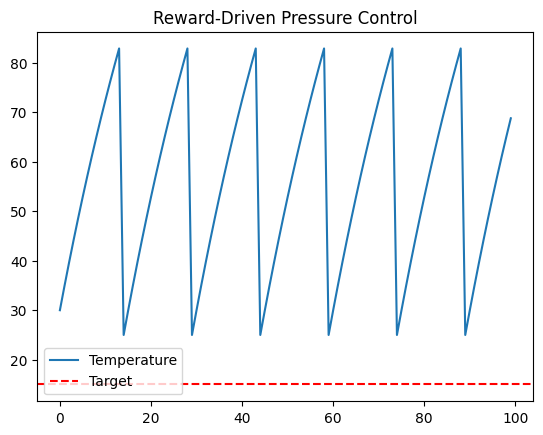

In [161]:
# 테스트 실행
import random
import torch.optim as optim
from collections import deque


model = bc_model
env = model.get_env()
_pre_state = obs = env.reset()
press_history = []

memory = deque(maxlen=2000)
policy = model.policy

total_reward = 0
repeat_cnt = 100 # 100

print(f'액션, [내부온도, 습도, 무게, 표면온도, 현재RPM, 풍압], 보상, Done')
for _ in range(repeat_cnt):
    action, _pre_state = model.predict(obs, deterministic=True)
    obs, r, terminated, truncated = env.step(action)
    if terminated:
        print(f'terminated={terminated}')
    print(f'action={action[0]}, obs={obs}, r={r}, terminated={terminated}, total_r={total_reward}')
    total_reward += r
    memory.append((obs, action, r, obs, terminated))
    press_history.append(obs[0][0]) # 온도 기록
    if len(memory) > 32:
        action = torch.tensor(action)
        # print(f'action={action}')
        loss = -torch.log(action) * total_reward 
        model.policy.optimizer.zero_grad()
        loss.requires_grad_(True)
        loss.backward()
        model.policy.optimizer.step()
        memory.clear()

plt.plot(press_history, label='Temperature')
plt.axhline(15, color='r', linestyle='--', label='Target')
plt.title("Reward-Driven Pressure Control")
plt.legend()
plt.show()
# plt.plot(press_history, label='Air Pressure (Pa)')
# plt.axhline(15, color='r', linestyle='--', label='Target')
# plt.title("Reward-Driven Pressure Control")
# plt.legend()
# plt.show()